In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Andor
import matplotlib.patches as patches

In [49]:
cam = Andor.Andor(-50)

In [50]:
cam.get_temperature()

-47.44599914550781

# Setup the ROI and Upper limit

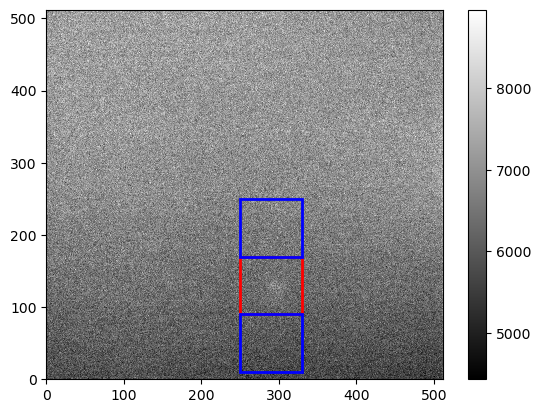

In [51]:
exposure_upper = 0.001
EMGain = 255

cam.set_acquisition_region(1,1,cam.hstart,cam.hend,cam.vstart,cam.vend)
cam.set_single_acquisition(exposure_time = exposure_upper,EMGain = EMGain)

cam.set_shutter(1)
cam.start_acquisition()
arr_sig = np.rot90(cam.get_acquired_data().reshape(512,512),-1)
plt.pcolormesh(arr_sig,cmap="gray")
plt.colorbar()


# Set up the ROI and Bg
x0, y0 = 250, 90# bottom-left corner of ROI
width, height = 80, 80   # side lengths of the square

# Draw ROI (red square)
rect = patches.Rectangle(
    (x0, y0), width, height,
    linewidth=2, edgecolor='red', facecolor='none'
)
plt.gca().add_patch(rect)

# Draw background regions (blue squares above and below ROI)
rect1 = patches.Rectangle(
    (x0, y0 + height), width, height,
    linewidth=2, edgecolor='blue', facecolor='none'
)
plt.gca().add_patch(rect1)

rect2 = patches.Rectangle(
    (x0, y0 - height), width, height,
    linewidth=2, edgecolor='blue', facecolor='none'
)
plt.gca().add_patch(rect2)

plt.show()

In [52]:
P = 25e-12    # laser power (W)
h = 6.63e-34  # Planck's constant (J·s)
c = 3e8       # speed of light (m/s)

# Backgroud corrected (Shutter closed for bg)

In [56]:
EMGain_list = [1,10,20,30,40,50,70,80,90,100,120,140,150,160,175,190,200,210,220,230,240,255]
Actual_list = []

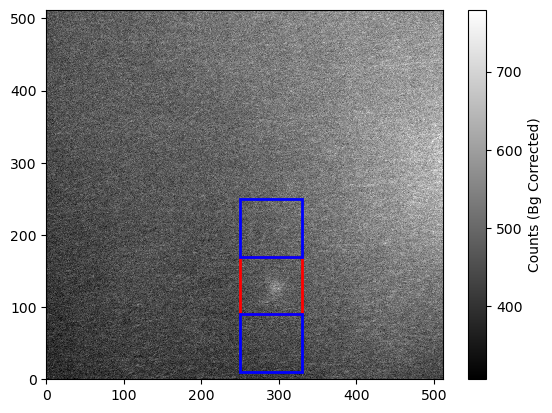

Background (BG): 467.399609375
Corrected counts (Nc): 62646.499999999935
Incident photons (Np): 5078431.372549022
Actual Gain: 0.3546541722972968


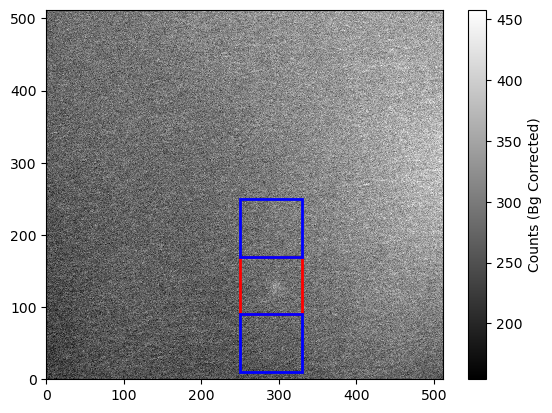

Background (BG): 280.197265625
Corrected counts (Nc): 28405.5
Incident photons (Np): 4901960.784313727
Actual Gain: 0.16659825749999993


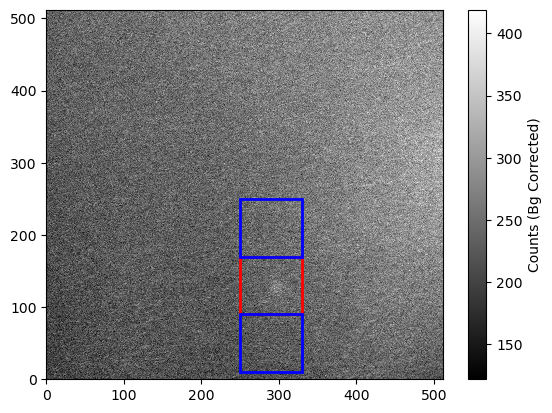

Background (BG): 237.12875
Corrected counts (Nc): 27555.000000000025
Incident photons (Np): 4705882.352941178
Actual Gain: 0.1683438281250001


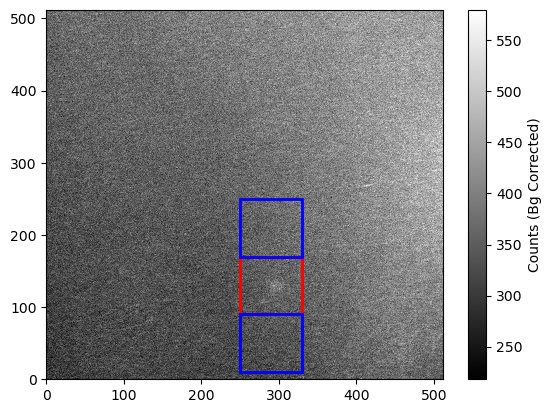

Background (BG): 350.02671875
Corrected counts (Nc): 25531.000000000087
Incident photons (Np): 4509803.921568629
Actual Gain: 0.1627601250000005


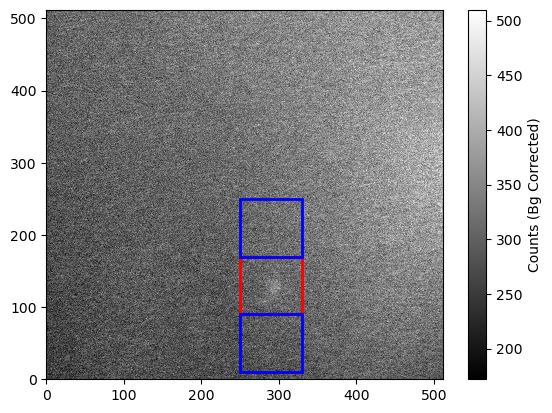

Background (BG): 303.809140625
Corrected counts (Nc): 35188.500000000015
Incident photons (Np): 4313725.49019608
Actual Gain: 0.2345233551136364


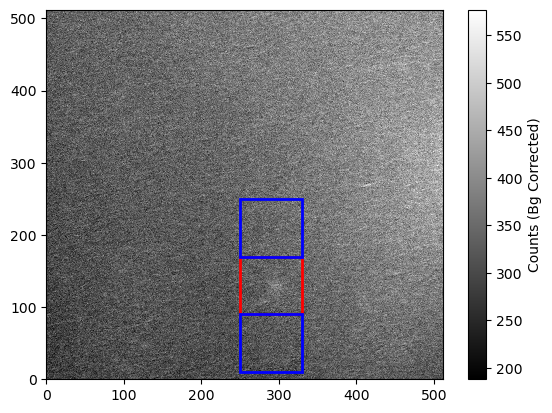

Background (BG): 333.60109375
Corrected counts (Nc): 33187.99999999988
Incident photons (Np): 4117647.058823531
Actual Gain: 0.23172335714285625


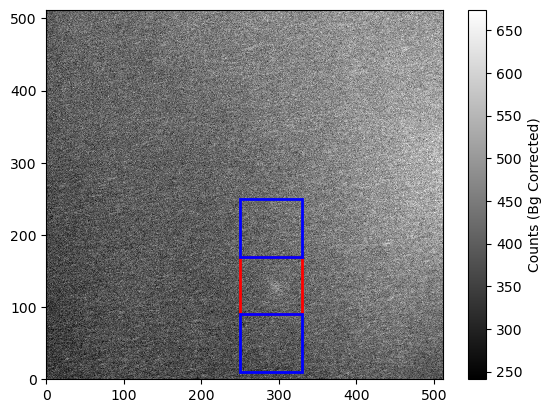

Background (BG): 406.45624999999995
Corrected counts (Nc): 40878.00000000029
Incident photons (Np): 3725490.196078433
Actual Gain: 0.3154598289473705


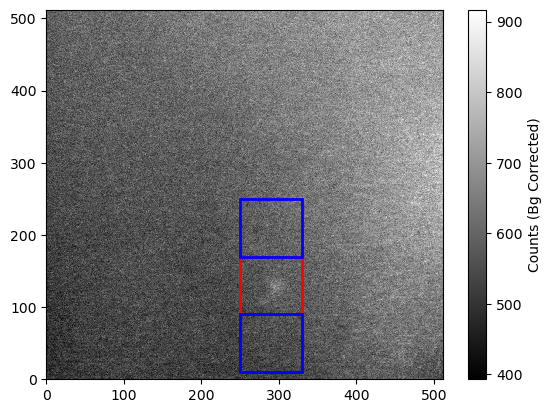

Background (BG): 572.003203125
Corrected counts (Nc): 47782.499999999825
Incident photons (Np): 3529411.7647058833
Actual Gain: 0.3892282812499984


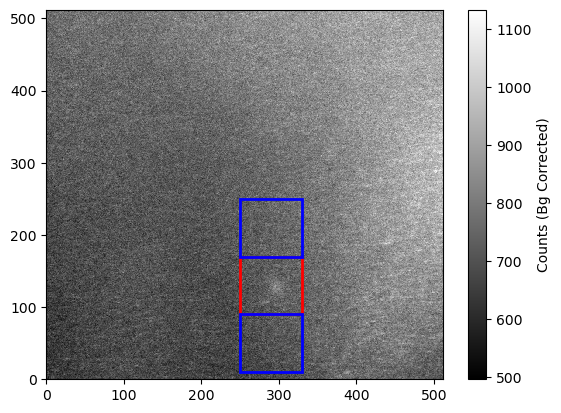

Background (BG): 723.77515625
Corrected counts (Nc): 55811.99999999994
Incident photons (Np): 3333333.3333333344
Actual Gain: 0.4813784999999994


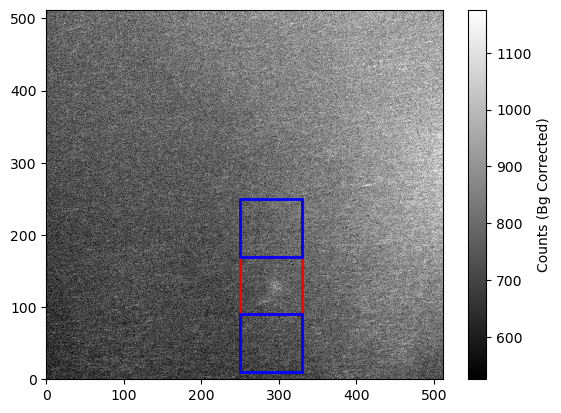

Background (BG): 752.77953125
Corrected counts (Nc): 55689.00000000006
Incident photons (Np): 3137254.901960785
Actual Gain: 0.5103374765625004


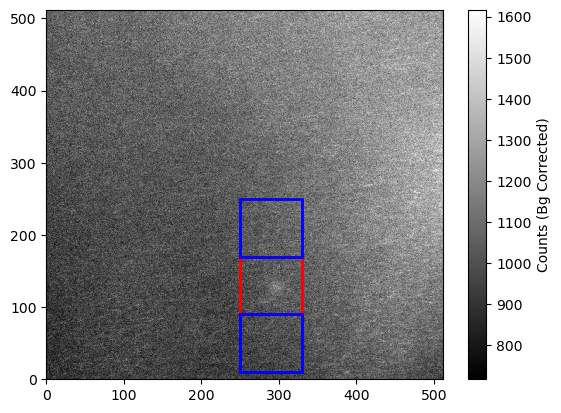

Background (BG): 1020.198515625
Corrected counts (Nc): 87450.49999999983
Incident photons (Np): 2745098.039215687
Actual Gain: 0.915887825892855


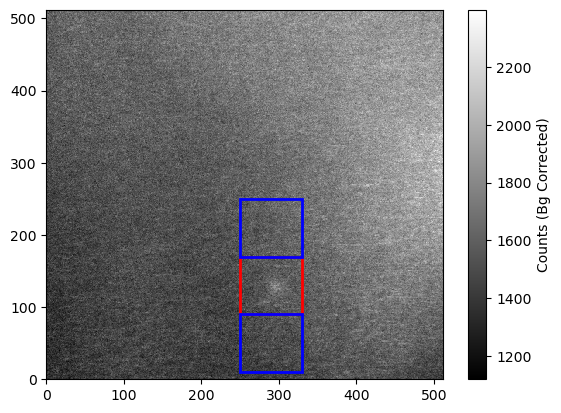

Background (BG): 1545.265859375
Corrected counts (Nc): 131240.50000000003
Incident photons (Np): 2352941.176470589
Actual Gain: 1.603594859375


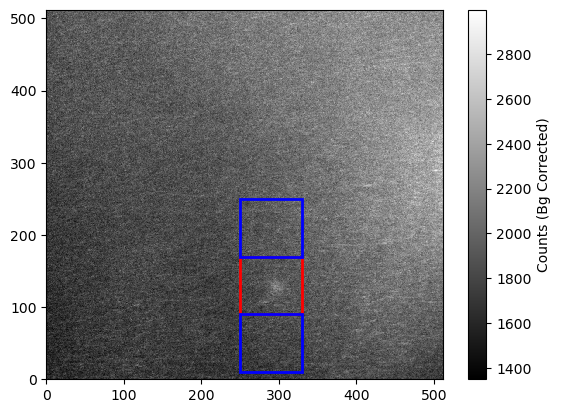

Background (BG): 1861.7540625
Corrected counts (Nc): 178595.0000000005
Incident photons (Np): 2156862.74509804
Actual Gain: 2.380590170454551


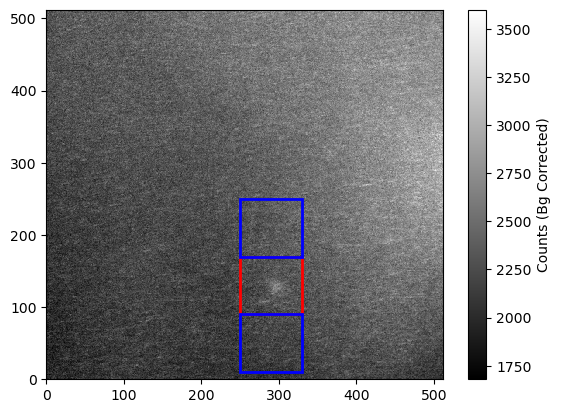

Background (BG): 2265.9884375
Corrected counts (Nc): 223223.99999999907
Incident photons (Np): 1960784.3137254906
Actual Gain: 3.2730218999999856


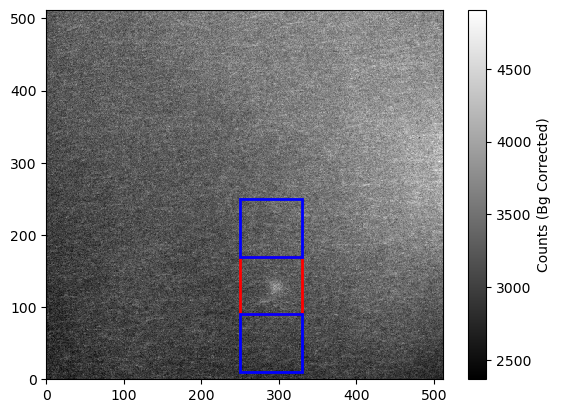

Background (BG): 3194.5125
Corrected counts (Nc): 337318.00000000116
Incident photons (Np): 1666666.6666666672
Actual Gain: 5.8187355000000185


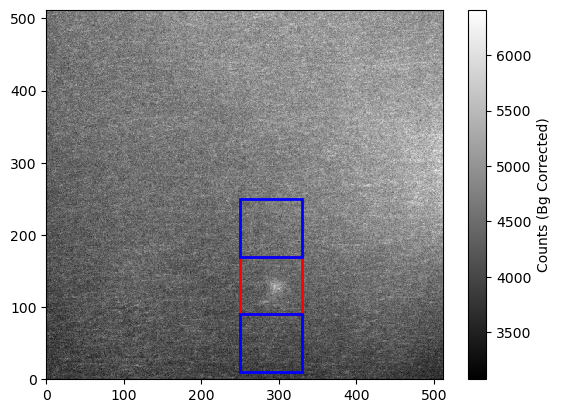

Background (BG): 4347.5103125000005
Corrected counts (Nc): 529649.9999999967
Incident photons (Np): 1372549.0196078438
Actual Gain: 11.09427589285707


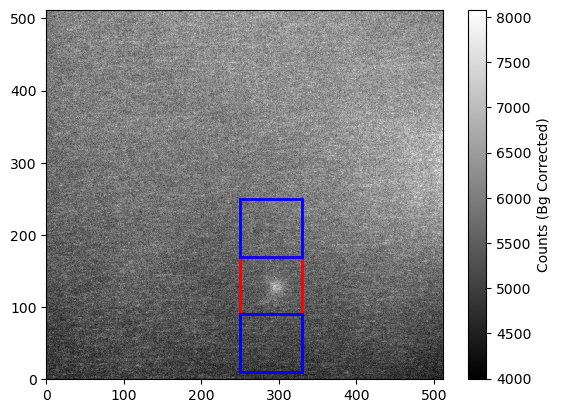

Background (BG): 5483.90578125
Corrected counts (Nc): 751973.0000000028
Incident photons (Np): 1176470.5882352944
Actual Gain: 18.376340187500066


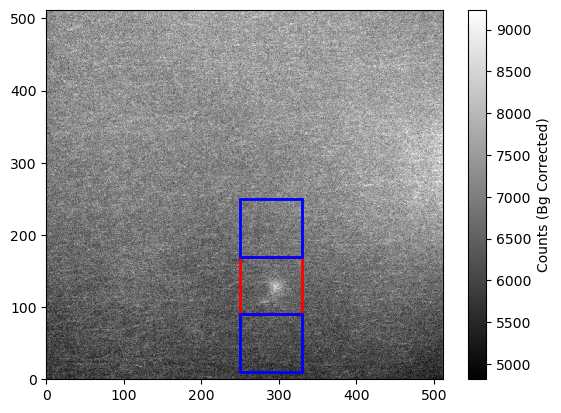

Background (BG): 6534.25
Corrected counts (Nc): 929662.0
Incident photons (Np): 980392.1568627455
Actual Gain: 27.262338149999987


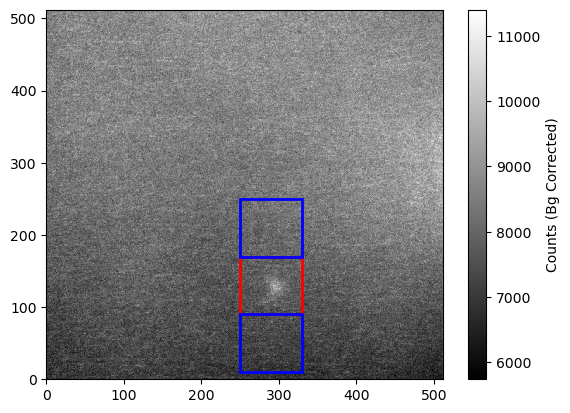

Background (BG): 7701.110546875
Corrected counts (Nc): 1021690.499999999
Incident photons (Np): 784313.7254901963
Actual Gain: 37.45134239062495


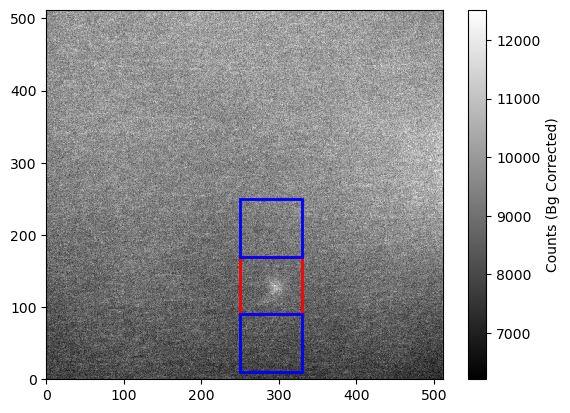

Background (BG): 8736.61390625
Corrected counts (Nc): 1057442.9999999963
Incident photons (Np): 588235.2941176472
Actual Gain: 51.6825266249998


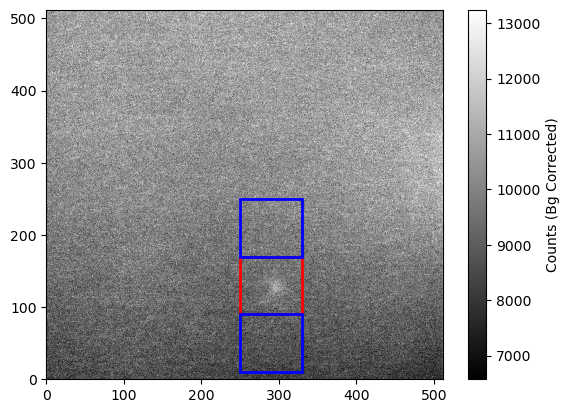

Background (BG): 9332.92390625
Corrected counts (Nc): 1135586.9999999995
Incident photons (Np): 392156.86274509813
Actual Gain: 83.25272193749994


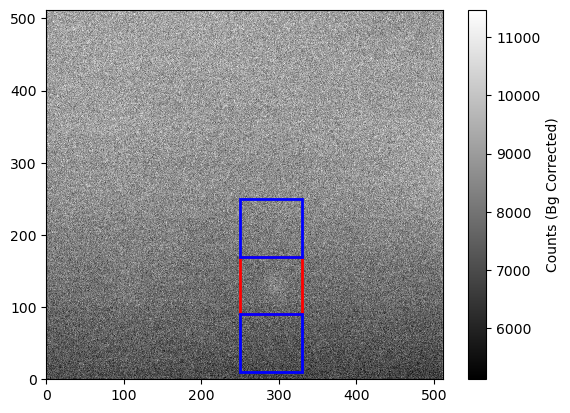

Background (BG): 7841.465859375
Corrected counts (Nc): 624705.4999999998
Incident photons (Np): 98039.21568627453
Actual Gain: 183.1948878749999


In [57]:
for EMGain in EMGain_list:
    exposure = exposure_upper - 0.05/250*(EMGain-255)

    cam.set_single_acquisition(exposure_time = exposure, EMGain = EMGain)
    
    # Collect the signal data
    cam.set_shutter(1)
    cam.start_acquisition()
    arr_sig = cam.get_acquired_data()

    # Collect the bg data
    cam.set_shutter(0)
    cam.start_acquisition()
    arr_bg = cam.get_acquired_data()

    arr_diff = np.rot90((arr_sig-arr_bg).reshape(cam.width,cam.height),-1)
    
    # Display the data as an image
    plt.pcolormesh(arr_diff, cmap='gray')
    plt.colorbar(label='Counts (Bg Corrected)')
        
    # Draw ROI (red square)
    rect = patches.Rectangle(
        (x0, y0), width, height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    plt.gca().add_patch(rect)
    
    # Draw background regions (blue squares above and below ROI)
    rect1 = patches.Rectangle(
        (x0, y0 + height), width, height,
        linewidth=2, edgecolor='blue', facecolor='none'
    )
    plt.gca().add_patch(rect1)
    
    rect2 = patches.Rectangle(
        (x0, y0 - height), width, height,
        linewidth=2, edgecolor='blue', facecolor='none'
    )
    plt.gca().add_patch(rect2)
    
    plt.show()
    
    # Calculate background (average of upper and lower regions)
    BG1 = np.mean(arr_diff[y0 + height : y0 + 2 * height, x0 : x0 + width])
    BG2 = np.mean(arr_diff[y0 - height : y0, x0 : x0 + width])
    BG = (BG1 + BG2) / 2
    print("Background (BG):", BG)
    
    # Extract the region of interest (ROI)
    ROI = arr_diff[y0 : y0 + height, x0 : x0 + width]
    
    # Calculate corrected photon counts in ROI
    Nc = np.sum(ROI - BG)
    print("Corrected counts (Nc):", Nc)
    
    
    # Number of incident photons
    Np = P * exposure / (h * (c / 780e-9))
    print("Incident photons (Np):", Np)
    
    # Actual gain calculation
    Actual_Gain = 23 / 0.8 * Nc / Np
    print("Actual Gain:", Actual_Gain)

    Actual_list.append(Actual_Gain)

Text(0.5, 1.0, 'calibration curve at -50C')

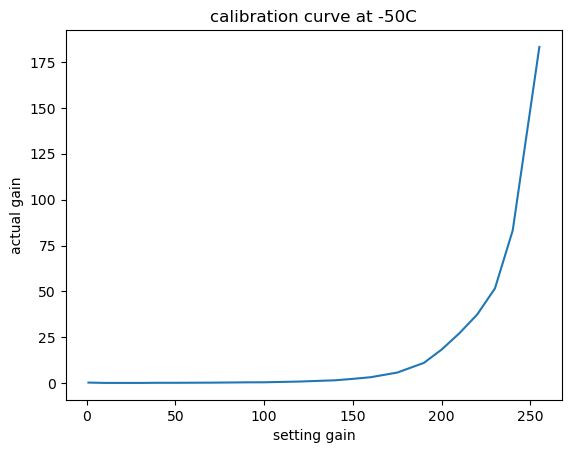

In [58]:
plt.plot(EMGain_list,Actual_list)
# print(Actual_list)
plt.xlabel("setting gain")
plt.ylabel("actual gain")
plt.title("calibration curve at -50C")

In [48]:
cam.shutdown()

camera is successfully shutdown


# Backgroud corrected (Shutter always on)